<a href="https://colab.research.google.com/github/msenattt/Product-analytic-Python/blob/main/%D0%9F%D1%80%D0%BE%D0%B4%D1%83%D0%BA%D1%82%D0%BE%D0%B2%D0%B0%D1%8F_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_%D0%A2_%D0%91%D0%B0%D0%BD%D0%BA_%D0%BF%D1%80%D0%B5%D0%B4%D0%B8%D0%BD%D1%82%D0%B5%D0%BD%D1%81%D0%B8%D0%B2_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving dataset-sots-seti-b62e6c94-57c9-4f77-a11f-4f9cd2af3e4e.xlsx to dataset-sots-seti-b62e6c94-57c9-4f77-a11f-4f9cd2af3e4e.xlsx


In [4]:
import pandas as pd

df = pd.read_excel('dataset-sots-seti-b62e6c94-57c9-4f77-a11f-4f9cd2af3e4e.xlsx')
df.shape

(56820, 25)

In [13]:
df.head()

,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,...,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score,review_mark_clean
0,2025-02-18 15:41:00,2025-02-18 16:56:49.353,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,...,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN,1
1,2025-03-24 20:06:00,2025-03-28 17:42:39.772,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,...,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN,1
2,2025-07-08 07:40:43,2025-07-08 10:29:04.740,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN,5
3,2025-08-07 22:51:48,2025-08-08 09:35:34.593,5ca669878eaf593f68c10e163246357b,SME,5,Позитивный,banki.ru,sme,расчетный счет,Не определено,...,MAR,0.0,РФ,Высокодоходные без ПМ,0.0,0.0,1.0,Взрослые,NaN,5
4,2025-02-13 21:38:40,2025-02-14 08:04:44.643,7a436100b113ce78c8a7a02974521a16,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,...,NaN,0.0,РФ,Доходные,0.0,0.0,1.0,Сеньоры,NaN,5


In [6]:
df.isna().mean().sort_values(ascending=False) * 100

,0
csat_score,94.003872
education_level_cd,56.015488
marital_status_cd,33.164379
children_cnt,23.720521
segment_name,23.252376
influencer_flg,23.252376
new_flg,23.252376
subscription_important_flg,23.252376
age_segment,18.949314
review_text,3.690602


In [14]:
df.dtypes

,0
review_dttm,datetime64[ns]
finish_dttm,datetime64[ns]
id_client,object
company,object
review_mark,object
review_emotion,object
review_source,object
business_line,object
product,object
reason,object


In [11]:
df['review_mark'].value_counts(dropna=False)

,count
review_mark,
5,33785
1,9991
без оценки (негативный),8954
без оценки (нейтральный),1782
2,1096
4,590
3,475
без оценки (позитивный),147


In [9]:
df['review_emotion'].value_counts(dropna=False)

,count
review_emotion,
Позитивный,34522
Негативный,22298


In [10]:
df['new_flg'].value_counts(dropna=False)

,count
new_flg,
0.0,42666
NaN,13212
1.0,942


In [12]:
mark_mapping = {
    '1': 1, '2': 2, '3': 3, '4': 4, '5': 5,
    'без оценки (позитивный)': 5,
    'без оценки (нейтральный)': 3,
    'без оценки (негативный)': 1
}

df['review_mark_clean'] = df['review_mark'].map(mark_mapping)
df['review_mark_clean'].value_counts(dropna=False)

,count
review_mark_clean,
5,33932
1,18945
3,2257
2,1096
4,590


In [15]:
df['solution_flg_clean'] = df['solution_flg'].map({
    'проблема решена': 1,
    'не указано': 0
})

df['solution_flg_clean'].value_counts(dropna=False)

,count
solution_flg_clean,
0,43661
1,13159


In [16]:
df['time_to_resolve_hours'] = (df['finish_dttm'] - df['review_dttm']).dt.total_seconds() / 3600
df['time_to_resolve_hours'].describe()

,time_to_resolve_hours
count,56726.000000
mean,21.093619
std,82.268057
min,0.008706
25%,0.474414
50%,1.660381
75%,12.198427
max,5325.504787


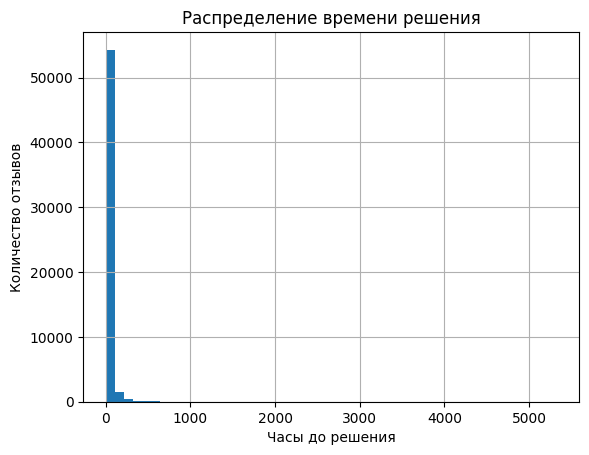

In [17]:
import matplotlib.pyplot as plt

df['time_to_resolve_hours'].hist(bins=50)
plt.xlabel('Часы до решения')
plt.ylabel('Количество отзывов')
plt.title('Распределение времени решения')
plt.show()

In [18]:
print('Доля решённых до 24 часов:', (df['time_to_resolve_hours'] <= 24).mean() * 100, '%')
print('Доля решённых до 168 часов (неделя):', (df['time_to_resolve_hours'] <= 168).mean() * 100, '%')
print('Доля решённых до 720 часов (месяц):', (df['time_to_resolve_hours'] <= 720).mean() * 100, '%')

Доля решённых до 24 часов: 84.45265751495951 %
Доля решённых до 168 часов (неделя): 97.51143963393172 %
Доля решённых до 720 часов (месяц): 99.56881379795847 %


In [19]:
pd.crosstab(df['new_flg'], df['review_emotion'], normalize='index') * 100

review_emotion,Негативный,Позитивный
new_flg,,
0.0,43.247551,56.752449
1.0,53.078556,46.921444


In [20]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['new_flg'], df['review_emotion'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print('Хи-квадрат статистика:', chi2)
print('p-value:', p_value)

Хи-квадрат статистика: 35.851786567381474
p-value: 2.1291270837962696e-09


In [21]:
df['review_theme'].value_counts(dropna=False).head(15)

,count
review_theme,
тарифы и условия,14080
страховое событие,8762
"платежи, переводы и операции",4898
карты,4365
кэшбек,4220
дополнительные услуги,2752
акции,2161
aml,2101
заявки,1983


In [22]:
top_themes = ['тарифы и условия', 'страховое событие', 'платежи, переводы и операции',
              'карты', 'кэшбек', 'дополнительные услуги', 'акции', 'aml']

df_top = df[df['review_theme'].isin(top_themes)]

result = pd.crosstab(df_top['review_theme'], df_top['new_flg'],
                      values=(df_top['review_emotion'] == 'Негативный').astype(int),
                      aggfunc='mean') * 100

print(result)

new_flg                             0.0        1.0
review_theme                                      
aml                           63.108922  68.000000
акции                         53.909692  52.564103
дополнительные услуги         13.301850  22.000000
карты                         93.370021  96.124031
кэшбек                        26.765432  33.928571
платежи, переводы и операции  27.231467  25.757576
страховое событие              6.338028   0.000000
тарифы и условия              18.355715  27.881041


In [23]:
counts = pd.crosstab(df_top['review_theme'], df_top['new_flg'])
print(counts)

new_flg                         0.0  1.0
review_theme                            
aml                            1827   25
акции                          1816   78
дополнительные услуги          2541   50
карты                          3816  129
кэшбек                         4050   56
платежи, переводы и операции   4627   66
страховое событие               142    1
тарифы и условия              12808  269


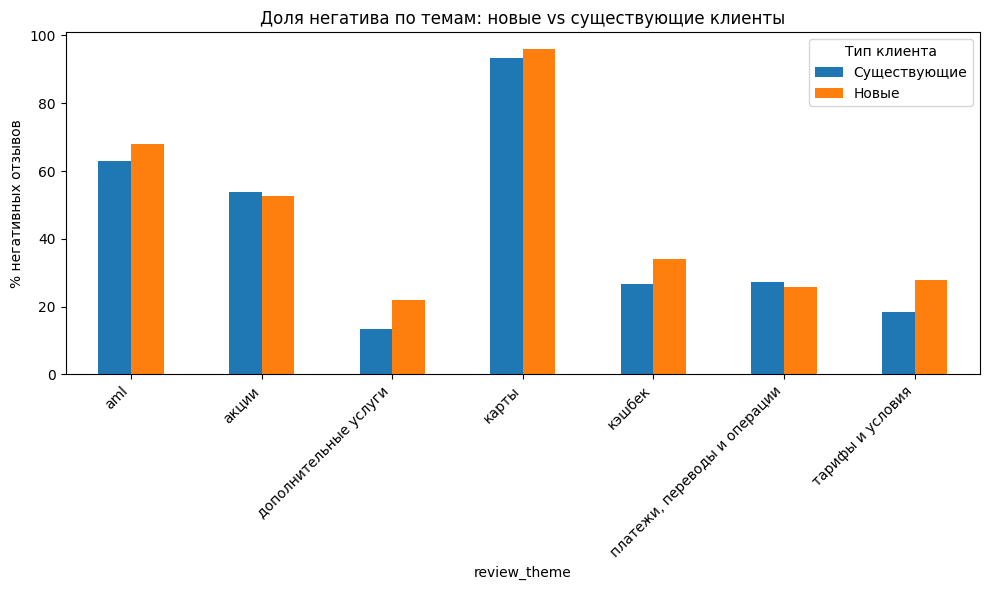

In [24]:
import matplotlib.pyplot as plt

# исключаем ненадёжную тему
plot_data = result.drop('страховое событие')
plot_data.columns = ['Существующие', 'Новые']

plot_data.plot(kind='bar', figsize=(10,6))
plt.ylabel('% негативных отзывов')
plt.title('Доля негатива по темам: новые vs существующие клиенты')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип клиента')
plt.tight_layout()
plt.show()

In [25]:
df_tariffs = df[df['review_theme'] == 'тарифы и условия']

table_tariffs = pd.crosstab(df_tariffs['new_flg'], df_tariffs['review_emotion'])
print(table_tariffs)

chi2_t, p_value_t, dof_t, expected_t = chi2_contingency(table_tariffs)
print('p-value:', p_value_t)

review_emotion  Негативный  Позитивный
new_flg                               
0.0                   2351       10457
1.0                     75         194
p-value: 9.688887590583861e-05
